# Unconditional diffusion prior diagnosis

The main reconstruction pipeline uses the authors’ FFHQ diffusion model as the image prior. Before interpreting failures in gradient-guided reconstruction, this experiment isolates that prior and asks a simpler question: can the diffusion model, using the authors’ implementation and checkpoint, generate human-looking 256×256 faces when no reconstruction information is provided?

The experiment is deliberately unconditional. No victim model, target image, gradient, measurement, GSS, or conditioning function is used. A successful result establishes that the diffusion model itself can produce the expected face domain; therefore, failures in later reconstructions should not automatically be attributed to an incapable generative prior.

All files are kept under a separate directory so that this diagnostic does not modify the existing reproduction outputs.

# CELL 0 — Configuration / Drive setup

This cell mounts Google Drive and creates the directory structure for the experiment. Four locations are kept separate: `repo/` for the authors’ code, `input/` for copied model artifacts, `output/` for generated samples and metadata, and `logs/` for experiment logs.

The separation is intentional. This experiment is meant to diagnose the diffusion prior independently of the main GGSS-R reproduction, so its files should not overwrite or become mixed with the existing reconstruction outputs. The printed paths make the storage layout explicit before the model is loaded.

In [ ]:
# ============================================================
# CELL 0 — Configuration / Drive setup
# ============================================================

from google.colab import drive
from pathlib import Path
import os
import sys

drive.mount("/content/drive")

# ------------------------------------------------------------
# Completely separate experiment directory
# ------------------------------------------------------------

EXPERIMENT_ROOT = Path(
    "/content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion"
).resolve()

REPO_ROOT = EXPERIMENT_ROOT / "repo"
INPUT_ROOT = EXPERIMENT_ROOT / "input"
OUTPUT_ROOT = EXPERIMENT_ROOT / "output"
LOG_ROOT = EXPERIMENT_ROOT / "logs"

for path in [
    REPO_ROOT,
    INPUT_ROOT,
    OUTPUT_ROOT,
    LOG_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

print("=" * 72)
print("EXPERIMENT A — UNCONDITIONAL DIFFUSION")
print("=" * 72)
print()
print("Experiment root :", EXPERIMENT_ROOT)
print("Repository      :", REPO_ROOT)
print("Input           :", INPUT_ROOT)
print("Output          :", OUTPUT_ROOT)
print("Logs            :", LOG_ROOT)

Mounted at /content/drive
EXPERIMENT A — UNCONDITIONAL DIFFUSION

Experiment root : /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion
Repository      : /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/repo
Input           : /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/input
Output          : /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/output
Logs            : /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/logs


Result: The Experiment A directory structure was created successfully and is separate from the existing reproduction.


# CELL 1 — Fresh authors’ repository

This cell clones the authors’ GGSS-R repository and checks out the exact commit being used throughout the previous notebooks for reproduction.

Pinning the repository to a specific commit is important because the diffusion implementation, sampler, or configuration could change between revisions.

The output shows that the cloned repository exactly matches the expected author commit.

In [ ]:
# ============================================================
# CELL 1 — Fresh authors' repository
# ============================================================

import subprocess
import shutil
import os

AUTHOR_REPO_URL = "https://github.com/mjyyhhxx/GGSS-R.git"

AUTHOR_COMMIT = (
    "b337ef1192f3a04a776042882a2d636724817775"
)

repo_runner = REPO_ROOT / "sample_condition_same_inputs.py"

if not repo_runner.exists():

    if REPO_ROOT.exists():
        print("Removing incomplete repository...")
        shutil.rmtree(REPO_ROOT)

    print("Cloning authors' repository...")

    subprocess.run(
        [
            "git",
            "clone",
            AUTHOR_REPO_URL,
            str(REPO_ROOT),
        ],
        check=True,
    )

else:
    print("Repository already exists.")

# ------------------------------------------------------------
# Checkout exact author commit
# ------------------------------------------------------------

subprocess.run(
    ["git", "checkout", AUTHOR_COMMIT],
    cwd=REPO_ROOT,
    check=True,
)

actual_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=REPO_ROOT,
    text=True,
).strip()

print()
print("Expected author commit:")
print(" ", AUTHOR_COMMIT)

print()
print("Actual checked-out commit:")
print(" ", actual_commit)

assert actual_commit == AUTHOR_COMMIT, (
    "Repository commit does not match the author commit "
    "used in the reproduction notebook."
)

print()
print("✓ Exact author commit confirmed.")

Removing incomplete repository...
Cloning authors' repository...

Expected author commit:
  b337ef1192f3a04a776042882a2d636724817775

Actual checked-out commit:
  b337ef1192f3a04a776042882a2d636724817775

✓ Exact author commit confirmed.


**Result.** The repository is pinned exactly to the intended author commit, so the subsequent diffusion code comes from the specified revision.


# CELL 2 — Extract authors’ `code.zip`

The repository contains the authors’ packaged source code in `code.zip`. This cell extracts the archive and moves the extracted contents into the repository root, so that the expected `guided_diffusion/`, `util/`, and `configs/` directories are available in their intended locations.

Existing extracted contents are removed first. This avoids mixing files from an earlier attempt with the current archive, which would weaken the reproducibility of the diagnostic.

The successful output confirms that the authors’ `code.zip` was found and extracted into the experiment repo.

In [ ]:
# ============================================================
# CELL 2 — Extract authors' code.zip
# ============================================================

import zipfile
import shutil

CODE_ZIP = REPO_ROOT / "code.zip"
EXTRACTED_CODE = REPO_ROOT / "code"

assert CODE_ZIP.is_file(), (
    f"Authors' code.zip not found:\n{CODE_ZIP}"
)

print("Extracting:")
print(" ", CODE_ZIP)

if EXTRACTED_CODE.exists():
    shutil.rmtree(EXTRACTED_CODE)

with zipfile.ZipFile(CODE_ZIP, "r") as z:
    z.extractall(REPO_ROOT)

# The ZIP normally creates:
# REPO_ROOT/code/...

assert EXTRACTED_CODE.is_dir(), (
    "Expected extracted directory was not found."
)

# Move contents from REPO_ROOT/code/ into REPO_ROOT/
for item in EXTRACTED_CODE.iterdir():

    destination = REPO_ROOT / item.name

    if destination.exists():
        if destination.is_dir():
            shutil.rmtree(destination)
        else:
            destination.unlink()

    shutil.move(
        str(item),
        str(destination),
    )

EXTRACTED_CODE.rmdir()

print("✓ Authors' code.zip extracted.")

Extracting:
  /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/repo/code.zip
✓ Authors' code.zip extracted.


**Result.** The authors’ packaged source was extracted successfully into the experiment repository.


# CELL 3 — Verify diffusion files

This cell checks the specific files required for the diffusion experiment. These include the authors’ U-Net and Gaussian diffusion implementations, utility modules, and the model and DDIM configuration files.

The purpose is to catch an incomplete extraction. Each required path is asserted, so a missing implementation file cannot be silently overlooked.

All required files are reported with `✓`, confirming that the diffusion implementation and its config files are present.

In [ ]:
# ============================================================
# CELL 3 — Verify diffusion files
# ============================================================

required_files = [
    REPO_ROOT / "guided_diffusion" / "unet.py",
    REPO_ROOT / "guided_diffusion" / "gaussian_diffusion.py",
    REPO_ROOT / "guided_diffusion" / "posterior_mean_variance.py",
    REPO_ROOT / "guided_diffusion" / "nn.py",
    REPO_ROOT / "guided_diffusion" / "fp16_util.py",
    REPO_ROOT / "util" / "img_utils.py",
    REPO_ROOT / "util" / "fastmri_utils.py",
    REPO_ROOT / "configs" / "model_config.yaml",
    REPO_ROOT / "configs" / "diffusion_ddim1000_config.yaml",
]

print("=" * 72)
print("DIFFUSION FILE CHECK")
print("=" * 72)

for path in required_files:
    exists = path.is_file()
    print(f"{'✓' if exists else '✗'} {path.relative_to(REPO_ROOT)}")
    assert exists, f"Missing required file: {path}"

print()
print("✓ Required diffusion files are present.")

DIFFUSION FILE CHECK
✓ guided_diffusion/unet.py
✓ guided_diffusion/gaussian_diffusion.py
✓ guided_diffusion/posterior_mean_variance.py
✓ guided_diffusion/nn.py
✓ guided_diffusion/fp16_util.py
✓ util/img_utils.py
✓ util/fastmri_utils.py
✓ configs/model_config.yaml
✓ configs/diffusion_ddim1000_config.yaml

✓ Required diffusion files are present.


**Result.** Every required diffusion source and config file is present, so the experiment can proceed using the expected implementation.


# CELL 4 — Import the official DPS FFHQ checkpoint

This cell copies the official `ffhq_10m.pt` checkpoint from the earlier reproduction into Experiment A’s own `input/checkpoint/` directory. The checkpoint is the only model artifact taken from the existing reproduction.

The file is copied rather than referenced in place so that Experiment A remains self-contained and does not modify the original reproduction directory. The source, destination, and file size are printed. The copied checkpoint is reported as 357.07 MB.

In [ ]:
# ============================================================
# CELL 4 — Import official DPS FFHQ checkpoint
# ============================================================

import shutil
import hashlib

# ------------------------------------------------------------
# Existing artifact from the reproduction notebook
# ------------------------------------------------------------

EXISTING_CHECKPOINT = Path(
    "/content/drive/MyDrive/"
    "GGSS_R_unperturbed_reproduction/"
    "dps-checkpoint/"
    "ffhq_10m.pt"
).resolve()

# ------------------------------------------------------------
# New Experiment A copy
# ------------------------------------------------------------

CHECKPOINT_DIR = INPUT_ROOT / "checkpoint"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / "ffhq_10m.pt"

assert EXISTING_CHECKPOINT.is_file(), (
    "The official FFHQ checkpoint was not found at:\n"
    f"{EXISTING_CHECKPOINT}\n\n"
    "This is the only artifact Experiment A expects "
    "from the existing reproduction experiment."
)

print("Copying official checkpoint...")

shutil.copy2(
    EXISTING_CHECKPOINT,
    CHECKPOINT_PATH,
)

assert CHECKPOINT_PATH.is_file()

print()
print("Source:")
print(" ", EXISTING_CHECKPOINT)

print()
print("Experiment A copy:")
print(" ", CHECKPOINT_PATH)

print()
print("Size:")
print(
    f"  {CHECKPOINT_PATH.stat().st_size / (1024**2):.2f} MB"
)

Copying official checkpoint...

Source:
  /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/dps-checkpoint/ffhq_10m.pt

Experiment A copy:
  /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/input/checkpoint/ffhq_10m.pt

Size:
  357.07 MB


**Result.** The official FFHQ checkpoint was copied successfully into the experiment repo; the reported size is 357.07 MB.


# CELL 5 — Checkpoint verification

This cell verifies that the copied diffusion model is exactly the intended checkpoint. It first computes its SHA-256 and compares it with the expected hash from the existing reproduction notebook. It then loads the file with PyTorch and reports its type and number of stored parameter tensors.

The SHA-256 comparison is important because matching a filename or file size alone would not establish that the model contents are identical. A matching SHA provides a byte-level identity check before the checkpoint is used.

The expected and actual SHA-256 values match exactly. The checkpoint therefore passes both the integrity and loading checks.

In [ ]:
# ============================================================
# CELL 5 — Checkpoint verification
# ============================================================

import torch
import hashlib

EXPECTED_SHA256 = (
    "81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa"
)

print("=" * 72)
print("CHECKPOINT VERIFICATION")
print("=" * 72)

sha256 = hashlib.sha256()

with open(CHECKPOINT_PATH, "rb") as f:
    for chunk in iter(
        lambda: f.read(1024 * 1024),
        b"",
    ):
        sha256.update(chunk)

actual_sha256 = sha256.hexdigest()

print()
print("Expected SHA256:")
print(" ", EXPECTED_SHA256)

print()
print("Actual SHA256:")
print(" ", actual_sha256)

assert actual_sha256 == EXPECTED_SHA256, (
    "Checkpoint SHA256 does not match the checkpoint "
    "used in the existing reproduction."
)

print()
print("Loading checkpoint with PyTorch...")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("✓ torch.load() succeeded")

print()
print("Checkpoint type:")
print(" ", type(checkpoint))

if isinstance(checkpoint, dict):
    print()
    print("Number of parameters:")
    print(" ", len(checkpoint))

print()
print("✓ Official FFHQ checkpoint verified.")

CHECKPOINT VERIFICATION

Expected SHA256:
  81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa

Actual SHA256:
  81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa

Loading checkpoint with PyTorch...
✓ torch.load() succeeded

Checkpoint type:
  <class 'collections.OrderedDict'>

Number of parameters:
  362

✓ Official FFHQ checkpoint verified.


**Result.** The expected and actual SHA-256 are identical. The checkpoint also loads successfully as an `OrderedDict`, confirming both integrity and readability.


# CELL 6 — Dependencies / device

This cell records the software and hardware environment used for sampling. It reports the PyTorch version, CUDA device and version, and GPU model.

This information is relevant because the experiment performs four complete 1000-step, 256×256 diffusion trajectories. Runtime measurements later in the notebook should be interpreted in the context of this hardware and software environment.

The recorded environment is PyTorch 2.11.0+cu128, device `cuda:0`, Tesla T4, and CUDA 12.8.

In [ ]:
# ============================================================
# CELL 6 — Dependencies / device
# ============================================================

!pip -q install pyyaml scipy matplotlib tqdm

import torch
import yaml
import numpy as np
import matplotlib.pyplot as plt

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
    print("CUDA   :", torch.version.cuda)
else:
    print()
    print("WARNING: CUDA is unavailable.")
    print("This experiment will be extremely slow on CPU.")

PyTorch: 2.11.0+cu128
Device : cuda:0
GPU    : Tesla T4
CUDA   : 12.8


**Result.** The recorded runtime is PyTorch 2.11.0+cu128 on a Tesla T4 with CUDA 12.8.


# CELL 7 — Load authors’ configurations

This cell reads the model and diffusion YAML files directly from the checked-out authors’ repository. This ensures that the model architecture and diffusion settings remain those specified by the authors.

Several assertions make the intended experiment explicit. The model operates at 256×256 resolution, `class_cond=False` confirms that generation is unconditional, `learn_sigma=True` preserves the learned-variance configuration, and the sampler is DDIM with 1000 steps.

The printed configuration shows the 128-channel U-Net, one residual block, attention at resolution 16, learned sigma, and the linear noise schedule. The diffusion configuration uses DDIM and 1000 steps. The final assertion confirms the intended unconditional 256×256 DDIM-1000 setup.

In [ ]:
# ============================================================
# CELL 7 — Load authors' configurations
# ============================================================

MODEL_CONFIG_PATH = (
    REPO_ROOT /
    "configs" /
    "model_config.yaml"
)

DIFFUSION_CONFIG_PATH = (
    REPO_ROOT /
    "configs" /
    "diffusion_ddim1000_config.yaml"
)

with open(MODEL_CONFIG_PATH, "r") as f:
    model_config = yaml.safe_load(f)

with open(DIFFUSION_CONFIG_PATH, "r") as f:
    diffusion_config = yaml.safe_load(f)

# Make the checkpoint path explicit for this experiment.
# The architecture/configuration remains the authors' configuration.

model_config["model_path"] = str(CHECKPOINT_PATH)

print("=" * 72)
print("MODEL CONFIG")
print("=" * 72)

for key, value in model_config.items():
    print(f"{key}: {value}")

print()
print("=" * 72)
print("DIFFUSION CONFIG")
print("=" * 72)

for key, value in diffusion_config.items():
    print(f"{key}: {value}")

assert model_config["image_size"] == 256
assert model_config["class_cond"] is False
assert model_config["learn_sigma"] is True

assert diffusion_config["sampler"] == "ddim"
assert diffusion_config["steps"] == 1000

print()
print("✓ Authors' unconditional 256×256 DDIM-1000 setup confirmed.")

MODEL CONFIG
image_size: 256
num_channels: 128
num_res_blocks: 1
channel_mult: 
learn_sigma: True
class_cond: False
use_checkpoint: False
attention_resolutions: 16
num_heads: 4
num_head_channels: 64
num_heads_upsample: -1
use_scale_shift_norm: True
dropout: 0.0
resblock_updown: True
use_fp16: False
use_new_attention_order: False
model_path: /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/input/checkpoint/ffhq_10m.pt

DIFFUSION CONFIG
sampler: ddim
steps: 1000
noise_schedule: linear
model_mean_type: epsilon
model_var_type: learned_range
dynamic_threshold: False
clip_denoised: True
rescale_timesteps: False
timestep_respacing: 1000

✓ Authors' unconditional 256×256 DDIM-1000 setup confirmed.


**Result.** The requested unconditional 256×256 DDIM-1000 configuration is confirmed, including `class_cond=False` and the authors’ 1000-step DDIM sampler.


# CELL 8 — Load authors’ diffusion model + sampler

This cell imports the authors’ own `create_model()` and `create_sampler()` functions, and uses them to construct the diffusion U-Net and DDIM sampler. The repository is placed on the Python path because the authors’ implementation expects its original module structure.

The U-Net is moved to the selected device and set to evaluation mode. The sampler is created from the previously loaded diffusion configuration, keeping the sampling procedure tied to the authors’ implementation rather than a separate DDIM reimplementation.

The model loads successfully with 93,563,910 parameters, and the DDIM sampler reports `eta: 1`.

In [ ]:
# ============================================================
# CELL 8 — Load authors' diffusion model + sampler
# ============================================================

import os
import sys

# create_model() expects the repository's relative environment
# for the checkpoint/configuration.

os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from guided_diffusion.unet import create_model
from guided_diffusion.gaussian_diffusion import create_sampler

print("Creating authors' U-Net...")

model = create_model(
    **model_config
)

model = model.to(DEVICE)
model.eval()

print()
print("Creating authors' DDIM sampler...")

sampler = create_sampler(
    **diffusion_config
)

print()
print("✓ Diffusion model loaded.")
print("✓ DDIM sampler loaded.")
print()
print("Parameter count:")

num_parameters = sum(
    p.numel()
    for p in model.parameters()
)

print(f"  {num_parameters:,}")

Creating authors' U-Net...

Creating authors' DDIM sampler...
eta: 1

✓ Diffusion model loaded.
✓ DDIM sampler loaded.

Parameter count:
  93,563,910


**Result.** The authors’ U-Net and DDIM sampler load successfully. The U-Net contains 93,563,910 parameters and the sampler reports `eta: 1`.


# CELL 9 — Checkpoint/model consistency

This cell performs a parameter-by-parameter comparison between the loaded U-Net and `ffhq_10m.pt`. It checks that the checkpoint and model contain exactly the same parameter keys.

This is a stronger check than simply confirming that the checkpoint can be loaded. It tests whether the model actually used for sampling is numerically identical to the supplied checkpoint, removing checkpoint-loading ambiguity from the later image-quality diagnosis.

All 362 parameter tensors of the sampling model matches the verified checkpoint exactly.

In [ ]:
# ============================================================
# CELL 9 — Checkpoint/model consistency
# ============================================================

print("=" * 72)
print("MODEL / CHECKPOINT CONSISTENCY CHECK")
print("=" * 72)

state_dict = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

model_state = model.state_dict()

assert set(state_dict.keys()) == set(model_state.keys()), (
    "Checkpoint keys do not exactly match model keys."
)

max_difference = 0.0
checked = 0

for key in state_dict.keys():

    a = state_dict[key].detach().cpu()
    b = model_state[key].detach().cpu()

    difference = torch.max(
        torch.abs(a - b)
    ).item()

    max_difference = max(
        max_difference,
        difference
    )

    checked += 1

print("Parameters checked:", checked)
print("Maximum absolute difference:", max_difference)

assert max_difference == 0.0, (
    "The model parameters do not exactly match "
    "the supplied checkpoint."
)

print()
print("✓ Model weights exactly match ffhq_10m.pt.")

MODEL / CHECKPOINT CONSISTENCY CHECK
Parameters checked: 362
Maximum absolute difference: 0.0

✓ Model weights exactly match ffhq_10m.pt.


**Result.** All 362 parameter tensors match exactly, with maximum absolute difference 0.0. The model used for sampling is therefore identical to the verified checkpoint.


# CELL 10 — Unconditional sampling setup

This cell defines the sampling run used in this experiment: four 256×256 samples, the authors’ 1000-step DDIM sampler, and seed `12345`. Each sample will begin from Gaussian noise and will receive no conditioning information.

The primary visualization uses the model’s actual `[-1, 1]` output range, mapped to display space as

\[
x_{\mathrm{image}} = 
rac{x+1}{2}.
\]

The authors’ `clear_color()` behavior is deliberately not used as the primary diagnostic because it independently min-max normalizes each image. Such normalization can make images with poor absolute scaling look more visually structured than they are. The notebook therefore keeps the fixed model-range conversion as the main representation.

The output confirms four samples, 1000 diffusion steps, the authors’ DDIM sampler, and seed 12345. The run is stored under `output/unconditional_ddim1000`.

In [ ]:
# ============================================================
# CELL 10 — Unconditional sampling
# ============================================================

from pathlib import Path
from PIL import Image
import json
import time

# ------------------------------------------------------------
# Experiment settings
# ------------------------------------------------------------

NUM_SAMPLES = 4

IMAGE_SIZE = 256
SAVE_EVERY = 100

SEED = 12345

# Primary visualization uses the actual [-1, 1] model range:
#       image = (x + 1) / 2
# ------------------------------------------------------------

RUN_ROOT = OUTPUT_ROOT / "unconditional_ddim1000"
RUN_ROOT.mkdir(parents=True, exist_ok=True)

FINAL_ROOT = RUN_ROOT / "final_samples"
TRAJECTORY_ROOT = RUN_ROOT / "trajectories"

FINAL_ROOT.mkdir(parents=True, exist_ok=True)
TRAJECTORY_ROOT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 72)
print("EXPERIMENT A — UNCONDITIONAL SAMPLING")
print("=" * 72)
print()
print("Number of samples :", NUM_SAMPLES)
print("Diffusion steps   :", 1000)
print("Sampler           : authors' DDIM")
print("Seed              :", SEED)
print()
print("Output:")
print(" ", RUN_ROOT)

EXPERIMENT A — UNCONDITIONAL SAMPLING

Number of samples : 4
Diffusion steps   : 1000
Sampler           : authors' DDIM
Seed              : 12345

Output:
  /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/output/unconditional_ddim1000


**Result.** The run is configured for four independent unconditional samples using the full 1000-step DDIM trajectory and seed 12345.


# CELL 11 — Run the experiment

This is the core experiment. `run_unconditional_sample()` starts each trajectory from pure Gaussian noise,

\[
x_{999} \sim \mathcal{N}(0,I),
\]

and then traverses the authors’ DDIM timesteps backwards. At every step it calls the authors’ `sampler.p_sample()` and updates the current sample with the returned `sample` tensor.

No victim model, target image, measurement, GSS procedure, gradient, or conditioning function is involved. This isolation is the central point of this experiment: it tests the diffusion prior on its own.

The code also saves selected `x_t` states and `pred_xstart` estimates every 100 steps, including the beginning and end of the trajectory. The final tensors and final PNGs are saved as well. This makes it possible to inspect how structure develops during sampling rather than relying only on the last image.

All four 1000-step trajectories completed successfully. Their measured runtimes were 1.69, 1.72, 1.71, and 1.71 minutes, respectively. The comparable runtimes are consistent with four runs of the same sampling procedure on the Tesla T4. Successful completion establishes that the verified authors’ diffusion model and DDIM implementation can be executed end-to-end in this isolated setting.

In [ ]:
# ============================================================
# CELL 11 — RUN EXPERIMENT A
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def save_tensor_image_fixed(x, path):
    """
    Save a model-space image using the fixed [-1, 1] -> [0, 1]
    conversion.

    This is the primary visualization for Experiment A.
    """
    x = x.detach().float().cpu()

    if x.ndim == 4:
        x = x[0]

    x = x.clamp(-1.0, 1.0)
    x = (x + 1.0) / 2.0

    x = x.permute(1, 2, 0).numpy()

    plt.imsave(
        path,
        x,
    )


def save_tensor_image_author_style(x, path):
    """
    Save using the authors' clear_color() behavior:
    independent min-max normalization per image.

    This is secondary only, for comparison with author output.
    """
    x = x.detach().float().cpu()

    if x.ndim == 4:
        x = x[0]

    x = x.numpy()
    x = np.transpose(x, (1, 2, 0))

    x = x - x.min()

    denom = x.max()

    if denom > 0:
        x = x / denom

    plt.imsave(
        path,
        x,
    )


def run_unconditional_sample(sample_index):
    """
    One completely unconditional diffusion trajectory.

    No:
      - victim model
      - target image
      - measurement
      - GSS
      - gradient
      - conditioning function
    """

    sample_root = (
        TRAJECTORY_ROOT /
        f"sample_{sample_index:04d}"
    )

    x_root = sample_root / "x_t"
    x0_root = sample_root / "pred_xstart"

    x_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    x0_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    # --------------------------------------------------------
    # Start from pure Gaussian noise.
    # --------------------------------------------------------

    x = torch.randn(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE,
    )

    start_time = time.time()

    # --------------------------------------------------------
    # Authors' DDIM timesteps.
    #
    # create_sampler(... timestep_respacing=1000)
    # produces the full 0..999 trajectory.
    # The timesteps are traversed backwards.
    # --------------------------------------------------------

    timesteps = list(
        range(sampler.num_timesteps)
    )[::-1]

    with torch.no_grad():

        for idx in tqdm(
            timesteps,
            desc=f"sample {sample_index:04d}",
        ):

            t = torch.tensor(
                [idx],
                device=DEVICE,
                dtype=torch.long,
            )

            # ------------------------------------------------
            # THIS IS THE AUTHORS' ACTUAL DDIM STEP.
            #
            # No conditioning function is called.
            # ------------------------------------------------

            out = sampler.p_sample(
                model=model,
                x=x,
                t=t,
            )

            x = out["sample"]

            # ------------------------------------------------
            # Save selected trajectory points.
            # ------------------------------------------------

            if (
                idx % SAVE_EVERY == 0
                or idx == 999
                or idx == 0
            ):

                x_path = (
                    x_root /
                    f"x_{idx:04d}.png"
                )

                x0_path = (
                    x0_root /
                    f"x_{idx:04d}.png"
                )

                save_tensor_image_fixed(
                    x,
                    x_path,
                )

                save_tensor_image_fixed(
                    out["pred_xstart"],
                    x0_path,
                )

    elapsed = time.time() - start_time

    # --------------------------------------------------------
    # Save final tensors for later diagnostics.
    # --------------------------------------------------------

    torch.save(
        x.detach().cpu(),
        sample_root / "final_sample_tensor.pt",
    )

    torch.save(
        out["pred_xstart"].detach().cpu(),
        sample_root / "final_pred_xstart_tensor.pt",
    )

    # --------------------------------------------------------
    # Save final image.
    # --------------------------------------------------------

    final_path = (
        FINAL_ROOT /
        f"sample_{sample_index:04d}.png"
    )

    save_tensor_image_fixed(
        x,
        final_path,
    )

    return {
        "sample_index": sample_index,
        "seconds": elapsed,
        "final_path": str(final_path),
        "trajectory_path": str(sample_root),
    }


results = []

for sample_index in range(NUM_SAMPLES):

    result = run_unconditional_sample(
        sample_index
    )

    results.append(result)

    print()
    print(
        f"✓ Sample {sample_index} complete "
        f"({result['seconds'] / 60:.2f} min)"
    )

print()
print("=" * 72)
print("EXPERIMENT A COMPLETE")
print("=" * 72)

for result in results:
    print(
        f"Sample {result['sample_index']:04d}: "
        f"{result['seconds'] / 60:.2f} min"
    )

sample 0000:   0%|          | 0/1000 [00:00<?, ?it/s]


✓ Sample 0 complete (1.69 min)


sample 0001:   0%|          | 0/1000 [00:00<?, ?it/s]


✓ Sample 1 complete (1.72 min)


sample 0002:   0%|          | 0/1000 [00:00<?, ?it/s]


✓ Sample 2 complete (1.71 min)


sample 0003:   0%|          | 0/1000 [00:00<?, ?it/s]


✓ Sample 3 complete (1.71 min)

EXPERIMENT A COMPLETE
Sample 0000: 1.69 min
Sample 0001: 1.72 min
Sample 0002: 1.71 min
Sample 0003: 1.71 min


**Result.** All four unconditional trajectories completed successfully in approximately 1.7 minutes each. No reconstruction or conditioning computation was part of these runs.


# CELL 12 — Final sample contact sheet

This cell collects the four final PNG samples into a single 2×2 contact sheet. It first checks that exactly `NUM_SAMPLES` images were produced, resizes them to a common 256×256 display size, labels them by sample index, and saves the resulting sheet.

The contact sheet does not introduce another experiment. It just provides a single visual artifact for inspecting the four independent outputs of the unconditional diffusion prior. 

The output confirms that the contact sheet was saved successfully in the experiment's output directory.

Saved: /content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/output/unconditional_ddim1000/final_samples_contact_sheet.png


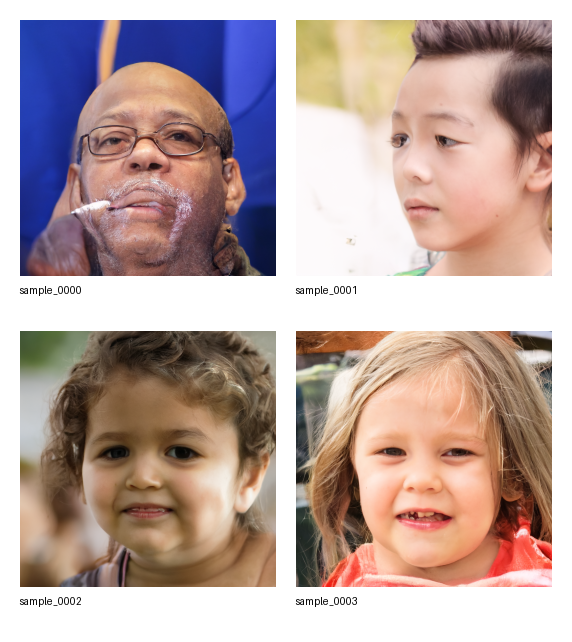

In [ ]:
# ============================================================
# CELL 12 — Final sample contact sheet
# ============================================================

from PIL import Image, ImageOps, ImageDraw
import math

image_paths = sorted(
    FINAL_ROOT.glob("sample_*.png")
)

assert len(image_paths) == NUM_SAMPLES

thumb_size = 256
margin = 20
label_height = 35

cols = 2
rows = math.ceil(NUM_SAMPLES / cols)

sheet_width = (
    cols * thumb_size
    + (cols + 1) * margin
)

sheet_height = (
    rows * (thumb_size + label_height)
    + (rows + 1) * margin
)

sheet = Image.new(
    "RGB",
    (sheet_width, sheet_height),
    "white",
)

draw = ImageDraw.Draw(sheet)

for i, image_path in enumerate(image_paths):

    img = Image.open(image_path).convert("RGB")
    img = img.resize(
        (thumb_size, thumb_size)
    )

    row = i // cols
    col = i % cols

    x = margin + col * (
        thumb_size + margin
    )

    y = margin + row * (
        thumb_size + label_height + margin
    )

    sheet.paste(
        img,
        (x, y),
    )

    draw.text(
        (x, y + thumb_size + 8),
        image_path.stem,
        fill="black",
    )

CONTACT_SHEET_PATH = (
    RUN_ROOT /
    "final_samples_contact_sheet.png"
)

sheet.save(
    CONTACT_SHEET_PATH
)

print(
    "Saved:",
    CONTACT_SHEET_PATH
)

display(sheet)

**Result.** The four final samples were assembled into and saved as a single contact sheet for qualitative inspection.


In [ ]:
# ============================================================
# CELL 13 — Experiment manifest
# ============================================================

manifest = {
    "experiment": "A_unconditional_diffusion",
    "description": (
        "Unconditional sampling from the authors' "
        "FFHQ diffusion model with no victim model, "
        "measurement, or GGSS conditioning."
    ),

    "author_repository": AUTHOR_REPO_URL,
    "author_commit": AUTHOR_COMMIT,

    "checkpoint_sha256": actual_sha256,

    "model_config": model_config,
    "diffusion_config": diffusion_config,

    "num_samples": NUM_SAMPLES,
    "seed": SEED,
    "save_every": SAVE_EVERY,

    "device": str(DEVICE),

    "output_root": str(RUN_ROOT),

    "results": results,
}

MANIFEST_PATH = (
    RUN_ROOT /
    "experiment_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
    )

print("Manifest:")
print(MANIFEST_PATH)

Manifest:
/content/drive/MyDrive/GGSS_R_experiment_A_unconditional_diffusion/output/unconditional_ddim1000/experiment_manifest.json


**Result.** The experiment manifest was saved successfully, preserving the implementation, checkpoint, configuration, sampling settings, device, and runtimes used in the experiment.
